In [50]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

In [2]:
home = Path.home()
data_path = home / 'Programming/data/fraud-detection/data'
data_df = pd.read_csv(
    data_path / 'transactions_obf.csv', parse_dates=['transactionTime'],
    dtype={'availableCash': np.float64, 'transactionAmount': np.float64}
    )
data_df.sort_values(by='transactionTime', inplace=True)

In [3]:
data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']] = data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']].astype('string')

In [4]:
labels_df = pd.read_csv(data_path / 'labels_obf.csv', parse_dates=['reportedTime'])
labels_df.sort_values(by='reportedTime', inplace=True)
data_df['fraudCase'] = data_df.eventId.isin(labels_df.eventId).astype(int)

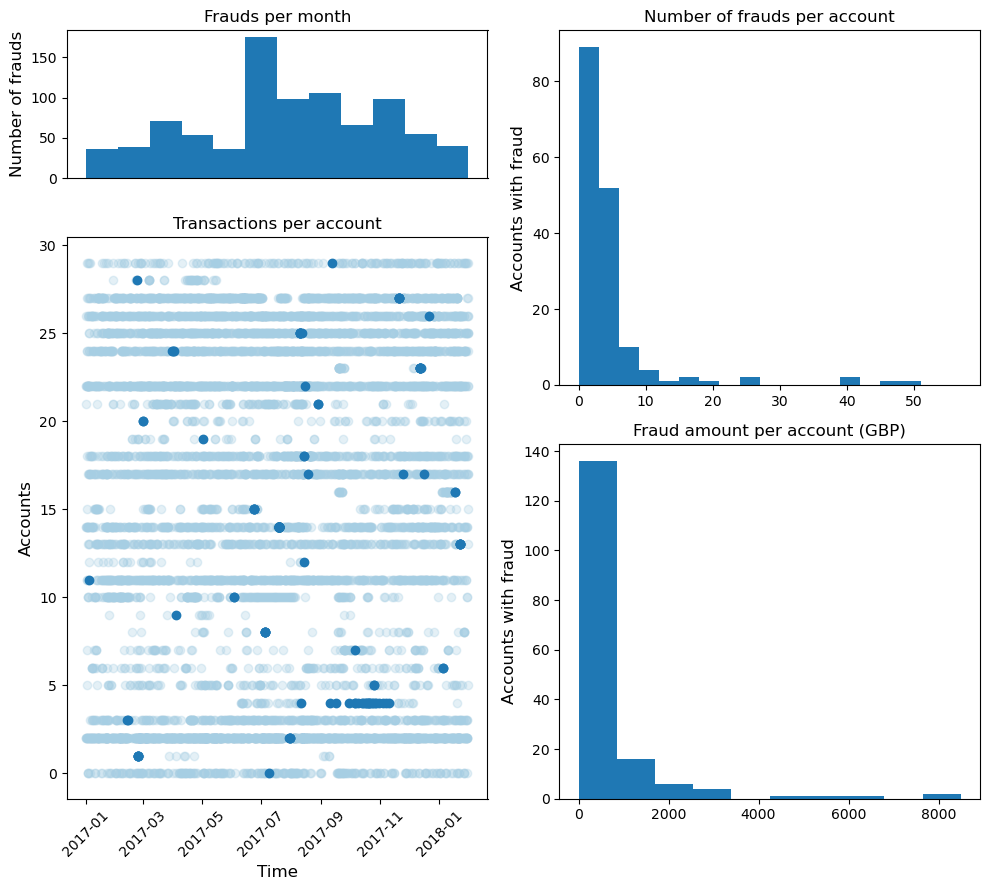

In [ ]:
mpl.rc('axes', labelsize=12)

df = data_df.copy()
y = data_df['fraudCase'].copy()
df['transactionTime'] = pd.to_datetime(df['transactionTime'])

fig, axes = plt.subplot_mosaic([['1.', '3.'], 
                               ['2.', '3.'], 
                               ['2.', '4.'],
                               ['2.', '4.']],
                               figsize=(10,9))

# transactions per account
plt.axes(axes['2.'])
acc_with_frauds = sorted(df['accountNumber'].loc[y==1].unique().tolist())
cmap=plt.cm.Paired.colors

for i in range(30):
    acc = acc_with_frauds[i]
    fraud = y[df['accountNumber']==acc]
    xx = df['transactionTime'].loc[df['accountNumber']==acc]
    plt.scatter(xx, np.ones(len(xx))*i, marker='o', color=cmap[0], alpha=0.3)
    plt.scatter(xx[fraud==1], np.ones(len(xx[fraud==1]))*i, color=cmap[1])

plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Accounts')
plt.title('Transactions per account')
plt.tight_layout()


# frauds per month
plt.axes(axes['1.'])
plt.hist(df['transactionTime'].loc[y==1], bins=12, color=cmap[1])
plt.xticks([])
plt.ylabel('Number of frauds')
plt.title('Frauds per month')
plt.tight_layout()


# number of frauds per account
label_encoder = LabelEncoder()
df.accountNumber = label_encoder.fit_transform(df.accountNumber)

num_fraud_per_account = []
for acc in range(max(df['accountNumber'])):
    num_fraud_per_account.append(sum(y[df['accountNumber']==acc]))
num_fraud_per_account = np.array([num_fraud_per_account])
tm = num_fraud_per_account[np.where(num_fraud_per_account>0)]

plt.axes(axes['3.'])
plt.hist(tm, bins=np.arange(0, 60, 3), color=cmap[1])
plt.title('Number of frauds per account')
plt.ylabel('Accounts with fraud')
plt.tight_layout()


# fraud amount per account
df_fraud = df.loc[y==1]
fraud_amount_per_account = df_fraud.groupby('accountNumber')['transactionAmount'].sum()

plt.axes(axes['4.'])
plt.hist(fraud_amount_per_account, color=cmap[1])
plt.title('Fraud amount per account (GBP)')
plt.ylabel('Accounts with fraud')
plt.tight_layout()


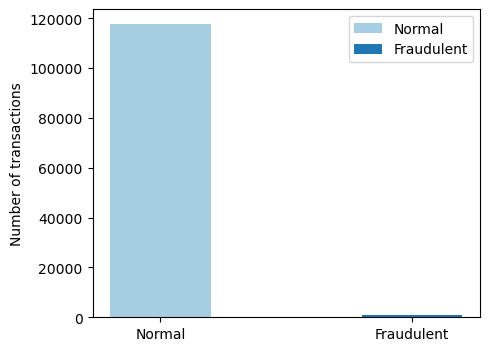

In [5]:
fig, ax = plt.subplots(figsize=(5,4))
ax.bar([0, 1], [(data_df.fraudCase == 0).sum(), (data_df.fraudCase == 1).sum()],
       width=0.4, color=plt.cm.Paired.colors, label=['Normal', 'Fraudulent'])
ax.set_xticks([0, 1], ['Normal', 'Fraudulent'])
ax.set_ylabel('Number of transactions')
ax.legend(loc='upper right');

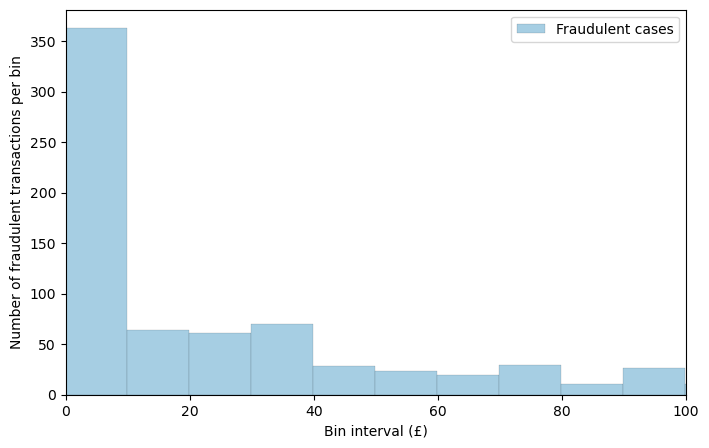

In [21]:
fig, ax = plt.subplots(figsize=(8,5))
amount_df = data_df.transactionAmount[data_df.fraudCase == 1]
sns.histplot(amount_df, bins=500, color=plt.cm.Paired.colors[0],
             ax=ax, label='Fraudulent cases', alpha=1.0)
ax.set_xlim([0, 100])
ax.set_xlabel('Bin interval (£)')
ax.set_ylabel('Number of fraudulent transactions per bin')
plt.legend();

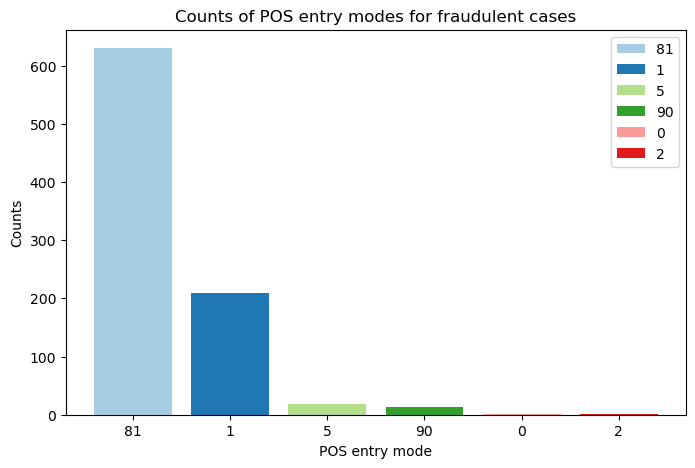

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
fraud_df = data_df[data_df.fraudCase == 1]
pos_fraud_df = fraud_df.posEntryMode.value_counts(ascending=False)
ax.bar(pos_fraud_df.index, pos_fraud_df.values,
       label=pos_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('POS entry mode')
ax.set_ylabel('Counts')
ax.set_title('Counts of POS entry modes for fraudulent cases')
plt.legend();

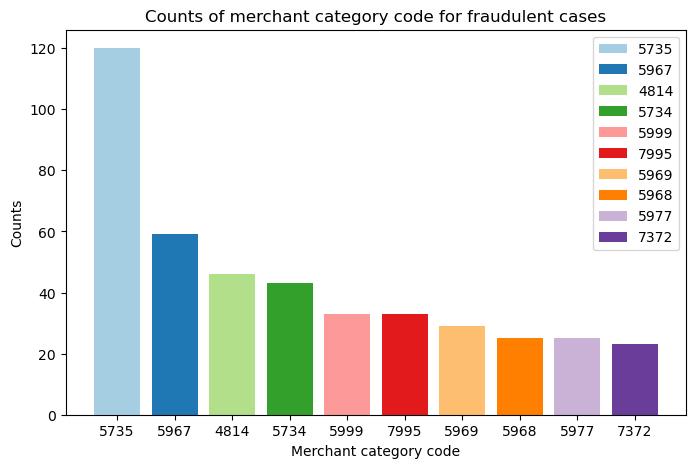

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mcc_fraud_df = fraud_df.mcc.value_counts(ascending=False)[:top_num]
ax.bar(mcc_fraud_df.index, mcc_fraud_df.values,
       label=mcc_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category code')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant category code for fraudulent cases')
plt.legend();

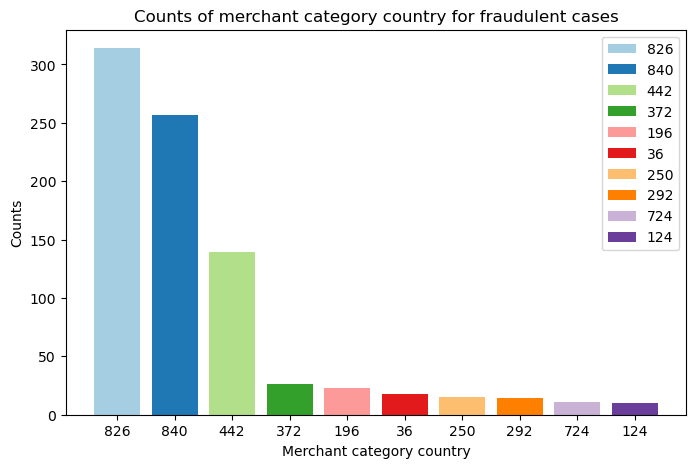

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mctry_fraud_df = fraud_df.merchantCountry.value_counts(ascending=False)[:top_num]
ax.bar(mctry_fraud_df.index, mctry_fraud_df.values,
       label=mctry_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category country')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant category country for fraudulent cases')
plt.legend();

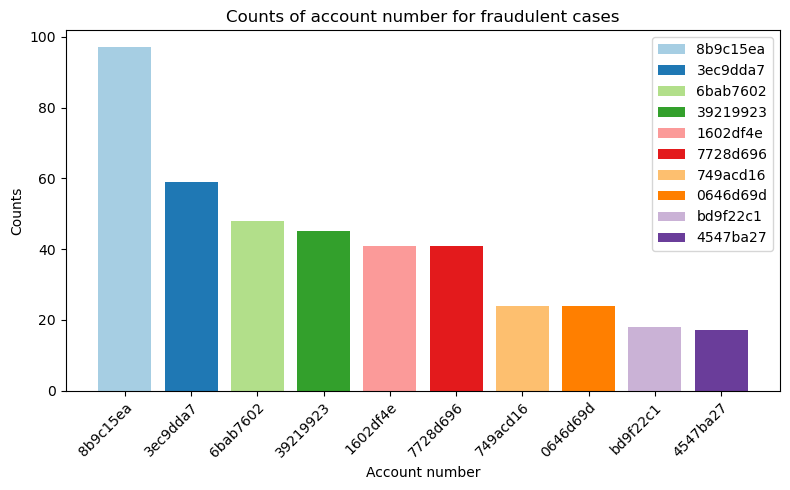

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
an_fraud_df = fraud_df.accountNumber.value_counts(ascending=False)[:top_num]
ax.bar(an_fraud_df.index, an_fraud_df.values, label=an_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Account number')
ax.set_ylabel('Counts')
ax.set_title('Counts of account number for fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.tight_layout()
plt.legend();

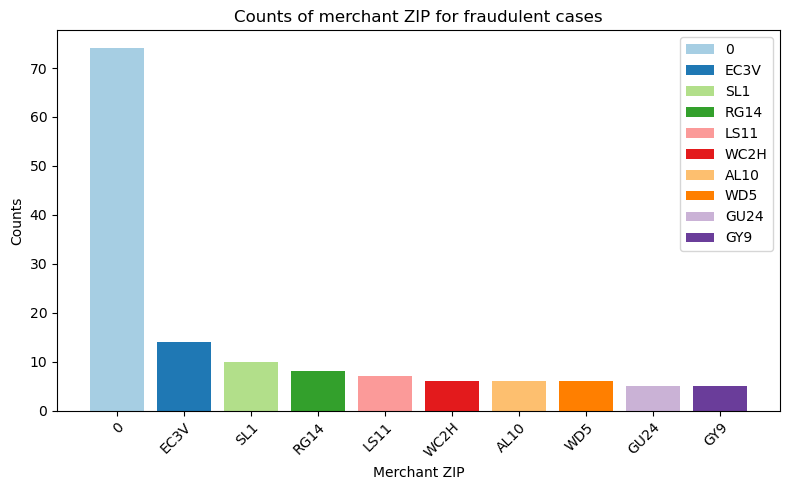

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mz_fraud_df = fraud_df.merchantZip.value_counts(ascending=False)[:top_num]
ax.bar(mz_fraud_df.index, mz_fraud_df.values, label=mz_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant ZIP')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant ZIP for fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.tight_layout()
plt.legend();